1) HLAVNÍ OTÁZKA

## Key Findings

1. **Top kluby nepřeplácí hráče – nakupují efektivněji než zbytek trhu**  
   Navzdory očekávání mají top kluby nižší price_ratio než ostatní, což naznačuje lepší scouting a vyjednávací pozici.

2. **Věk hráče má minimální vliv na rozdíl mezi cenou a tržní hodnotou**  
   Vysvětluje pouze ~1 % variability, což potvrzuje, že přestupové ceny nejsou primárně řízeny individuálními charakteristikami hráče.

3. **Původ hráče (liga) výrazně ovlivňuje jeho “cenovost”**  
   Některé ligy systematicky produkují “value” hráče (např. Bundesliga), zatímco jiné jsou spojeny s vyšším přeplácením.

4. **Cílová liga je nejsilnější faktor – přeplácení je řízeno poptávkou**  
   Ligy, do kterých hráči přestupují, mají největší vliv na price_ratio, což naznačuje, že trh je formován strukturou poptávky spíše než kvalitou hráče nebo chováním jednotlivých klubů.

## Problem Definition

Analyzuji, faktory které ovlivňují rozdíl mezi skutečnou přestupovou částkou a odhadovanou tržní hodnotou hráče.

Hlavní výzkumná otázka:
**Kdy a za jakých podmínek jsou hráči systematicky přepláceni?**

Zaměřuji se na tři klíčové faktory:
- vliv konkrétních klubů (kupujících i prodávajících)
- vliv ligy, ze které hráč přichází (origin)
- vliv ligy, do které hráč přestupuje (destination)

Analýza kombinuje exploratorní přístup s testováním konkrétních hypotéz.

2) FEATURE ENGINEERING

## Feature Engineering

Pro analýzu jsem vytvořila metriku:

- **price_ratio = transfer_fee / market_value**

Interpretace:
- < 1 → hráč byl nakoupen pod tržní hodnotou  
- ≈ 1 → odpovídá hodnotě  
- > 1 → hráč byl přeplacen

3) ANALYTICKÁ ČÁST

3.1 Club effect

### Club Effect

Prvním faktorem, který zkoumám, je vliv konkrétních klubů na přestupové ceny.

Zajímá mě, zda některé kluby systematicky přeplácí hráče, což může souviset s jejich finanční silou nebo strategií nákupu.

Pro analýzu identifikuji "top kluby" jako 10 klubů s nejvyššími výdaji (nákupy) a zároveň 10 klubů s nejvyššími příjmy (prodeje).

### Načtení dat

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("fotbal_prestupy_2000_2019.csv")
df.head()

,Jméno,Pozice,Věk,Původní tým,Původní liga,Nový tým,Nová Liga,Sezóna,Odhadovaná hodnota,Přestupová částka
0,Luís Figo,Right Winger,27,FC Barcelona,LaLiga,Real Madrid,LaLiga,2000-2001,NaN,60000000
1,Hernán Crespo,Centre-Forward,25,Parma,Serie A,Lazio,Serie A,2000-2001,NaN,56810000
2,Marc Overmars,Left Winger,27,Arsenal,Premier League,FC Barcelona,LaLiga,2000-2001,NaN,40000000
3,Gabriel Batistuta,Centre-Forward,31,Fiorentina,Serie A,AS Roma,Serie A,2000-2001,NaN,36150000
4,Nicolas Anelka,Centre-Forward,21,Real Madrid,LaLiga,Paris SG,Ligue 1,2000-2001,NaN,34500000


### Příprava dat

In [3]:
df_work = df.copy()

# odstranění chybějících hodnot pro klíčovou metriku
missing_share = df_work["Odhadovaná hodnota"].isna().mean()

df_work = df_work.dropna(subset=["Odhadovaná hodnota"])

print(f"Podíl odstraněných řádků kvůli chybějící hodnotě: {missing_share:.2%}")

Podíl odstraněných řádků kvůli chybějící hodnotě: 26.81%


Chybějící hodnoty v proměnné "Odhadovaná hodnota" tvoří přibližně 27 % datasetu.

Tyto záznamy odstraňuji, protože klíčová metrika price_ratio bez nich nelze spočítat.


Chybějící hodnoty (~27 %) mohou vést ke zkreslení výsledků, zejména pokud nejsou náhodné.

Dalším krokem by bylo ověřit, zda chybějící hodnoty souvisí např. s časem (starší sezóny) nebo konkrétními ligami.

V produkčním prostředí bych zvážila imputaci nebo segmentovanou analýzu.

### Feature engineering

price_ratio -> poměr umožňuje porovnávat hráče napříč různými cenovými hladinami

In [4]:
df_work["price_ratio"] = (
    df_work["Přestupová částka"] /
    df_work["Odhadovaná hodnota"]
)
df_work = df_work[df_work["Odhadovaná hodnota"] > 0]

### Identifikace top klubů

Každý přestup je označen podle toho, zda se týká top kupujícího nebo prodávajícího klubu.

In [7]:
top_buyers = club_spend.head(10).index
top_sellers = club_sell.head(10).index

# označení v datasetu
df_work["is_top_buying_club"] = df_work["Nový tým"].isin(top_buyers)
df_work["is_top_selling_club"] = df_work["Původní tým"].isin(top_sellers)

### Analýza vlivu top klubů

In [8]:
df_work.groupby("is_top_buyer")["price_ratio"].median()

is_top_buyer
False    1.238095
True     1.200000
Name: price_ratio, dtype: float64

Každý přestup je následně označen podle toho, zda se týká top kupujícího nebo prodávajícího klubu.

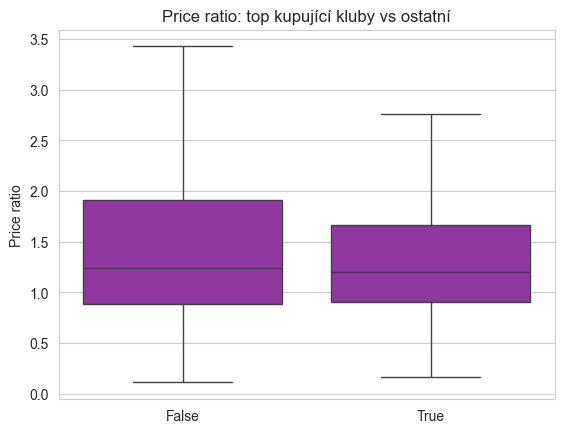

In [63]:
sns.boxplot(
    x="is_top_buying_club",
    y="price_ratio",
    data=df_work,
    color="#9C27B0",
    showfliers=False  
)

plt.title("Price ratio: top kupující kluby vs ostatní")
plt.xlabel("")
plt.ylabel("Price ratio")

plt.show()

In [10]:
df_work.groupby("is_top_selling_club")["price_ratio"].median()

is_top_selling_club
False    1.250000
True     1.115556
Name: price_ratio, dtype: float64

In [11]:
df_work.groupby("is_top_buying_club")["price_ratio"].agg(["median","mean","count"])

,median,mean,count
is_top_buying_club,,,
False,1.238095,2.544888,2829
True,1.200000,2.154606,611


Poznámka: Pro porovnání používám medián místo průměru, protože přestupové částky obsahují extrémní hodnoty (outliers). Medián je proto robustnější metrika pro zachycení typického chování trhu.

### Insight

Navzdory očekávání top kluby systematicky nepřeplácí hráče – naopak vykazují nižší price_ratio než zbytek trhu.

### Evidence

Medián price_ratio je u top klubů 1.20, zatímco u ostatních klubů 1.24.

### Interpretation

Finančně silné kluby zřejmě nevyužívají svou sílu k přeplácení, ale k efektivnějšímu nákupu – pravděpodobně díky lepšímu scoutingu, datům a vyjednávací pozici.

Tento výsledek jde proti intuitivní představě, že bohaté kluby “přeplácí” – data spíše ukazují opak

3.1.1 Controlling for age

### Controlling for player age

Přestupová cena může být ovlivněna dalšími faktory, zejména věkem hráče.

Abych tento vliv zohlednila, vytvořila jsem jednoduchý lineární model, který odhaduje očekávané price_ratio na základě věku hráče.

Na základě tohoto modelu jsem spočítala upravenou metriku (adjusted_ratio), která ukazuje odchylku od očekávané hodnoty.

In [13]:
from sklearn.linear_model import LinearRegression

X = df_work[['Věk']]
y = df_work['price_ratio']

model = LinearRegression()
model.fit(X, y)

df_work['expected_ratio'] = model.predict(X)
df_work['adjusted_ratio'] = df_work['price_ratio'] / df_work['expected_ratio']


In [14]:
model.score(X, y)

0.01286630614043971

Model vysvětluje pouze velmi malou část variability (R² ≈ 0.01), což naznačuje, že věk hráče má jen omezený vliv na price_ratio.

Z tohoto důvodu je interpretace adjusted_ratio spíše orientační a další faktory pravděpodobně hrají významnější roli.

In [ ]:
threshold_adj = df_work['adjusted_ratio'].quantile(0.1)
df_work['is_cheap_adjusted'] = df_work['adjusted_ratio'] <= threshold_adj

df_work.groupby("is_top_buying_club")["is_cheap_adjusted"].mean()
df_work.groupby("is_top_selling_club")["is_cheap_adjusted"].mean()


is_top_buying_club
False    0.095087
True     0.122750
Name: is_cheap_adjusted, dtype: float64

### Insight

Věk hráče má pouze minimální vliv na to, zda je hráč přeplacen.

### Evidence

Lineární model vysvětluje přibližně 1 % variability price_ratio (R² ≈ 0.01).

### Interpretation

Rozdíly v přestupových cenách nejsou taženy věkem hráče, ale spíše strukturálními faktory trhu, jako je vyjednávací síla, reputace klubů nebo efektivita scoutingu.

To posiluje závěr, že rozdíly mezi kluby nejsou artefaktem složení hráčů, ale skutečným rozdílem v jejich nákupní strategii.

3.2 Jsou některé ligy zdrojem ‘levnějších’ nebo ‘dražších’ hráčů?

Dalším faktorem, který zkoumám, je liga, ze které hráč přichází.

Cílem je zjistit, zda existují systematické rozdíly v přestupových cenách mezi ligami, a zda některé ligy představují zdroj relativně levnějších nebo dražších hráčů.

Pro každou ligu počítám medián price_ratio, který porovnává skutečnou přestupovou cenu s odhadovanou tržní hodnotou hráče.

Pro zajištění relevance výsledků zohledňuji pouze ligy s dostatečným počtem pozorování.

In [19]:
league_from_stats = (
    df_work
    .groupby("Původní liga")
    ["price_ratio"]
    .agg(["median", "mean", "count"])
    .sort_values("median")
)

league_from_stats.head(10)

,median,mean,count
Původní liga,,,
Croatia,0.300000,0.300000,1
1.Division,0.666667,0.666667,1
A Grupa - Championship gr.,0.750000,0.750000,1
1.Bundesliga,0.937500,1.137750,221
Chile,0.945455,20.578788,3
Argentina,1.000000,0.992063,3
2.Bundesliga,1.000000,1.167245,25
Bulgaria,1.000000,1.000000,1
Ekstraklasa,1.055556,1.381056,9


In [20]:
league_from_filtered = league_from_stats[league_from_stats["count"] >= 30]

In [21]:
top_cheap_leagues = league_from_filtered.head(5)
top_expensive_leagues = league_from_filtered.tail(5)

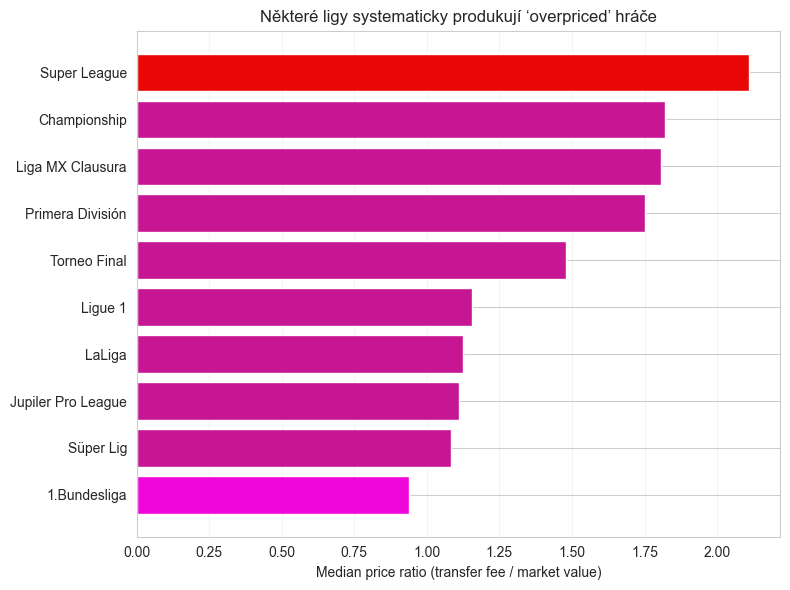

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) cleanup názvů lig ---
df_work["Původní liga"] = (
    df_work["Původní liga"]
    .str.strip()
    .replace({
        "Série A": "Serie A"
    })
)

# --- 2) agregace ---
league_from_stats = (
    df_work
    .groupby("Původní liga")["price_ratio"]
    .agg(["median", "mean", "count"])
)

# --- 3) filtr (relevantní ligy) ---
league_from_filtered = league_from_stats[league_from_stats["count"] >= 30]

# --- 4) výběr top/bottom ---
top_cheap = league_from_filtered.nsmallest(5, "median")
top_expensive = league_from_filtered.nlargest(5, "median")

plot_df = pd.concat([top_cheap, top_expensive]).sort_values("median")

# --- 5) plot ---
fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(plot_df.index, plot_df["median"], color="#4C72B0")

# osa X
ax.set_xlabel("Median price ratio (transfer fee / market value)")

# title 
ax.set_title("Některé ligy systematicky produkují ‘overpriced’ hráče")

colors = ["#C61694"] * len(plot_df)
colors[0] = "#EF07DC"   # nejlevnější
colors[-1] = "#E90606"  # nejdražší

ax.barh(plot_df.index, plot_df["median"], color=colors)

# grid
ax.grid(axis="x", alpha=0.2)

# layout
plt.tight_layout()
plt.show()

### Insight

Původ hráče (liga) má zásadní vliv na to, zda je hráč přeplacen – trh není homogenní.

### Evidence

Existují výrazné rozdíly v price_ratio mezi ligami: např. hráči ze Super League nebo Championship mají výrazně vyšší median price_ratio, zatímco hráči z Bundesligy patří mezi nejméně “přeplácené”.

### Interpretation

Některé ligy tak fungují jako „overpriced markets“, zatímco jiné jako „value markets“.  
To může odrážet rozdíly v reputaci lig, vyjednávací síle klubů nebo efektivitě scouting systémů.

Tento efekt je silnější než vliv konkrétního klubu, což naznačuje, že struktura trhu (liga) hraje klíčovou roli při formování přestupových cen.

3.3 Které ligy mají tendenci přeplácet hráče?

In [40]:
league_to_stats = (
    df_work
    .groupby("Nová  Liga")["price_ratio"]
    .agg(["median", "mean", "count"])
)

In [41]:
league_to_filtered = league_to_stats[league_to_stats["count"] >= 30]

In [42]:
top_cheap = league_to_filtered.nsmallest(5, "median")
top_expensive = league_to_filtered.nlargest(5, "median")

plot_df = pd.concat([top_cheap, top_expensive]).sort_values("median")

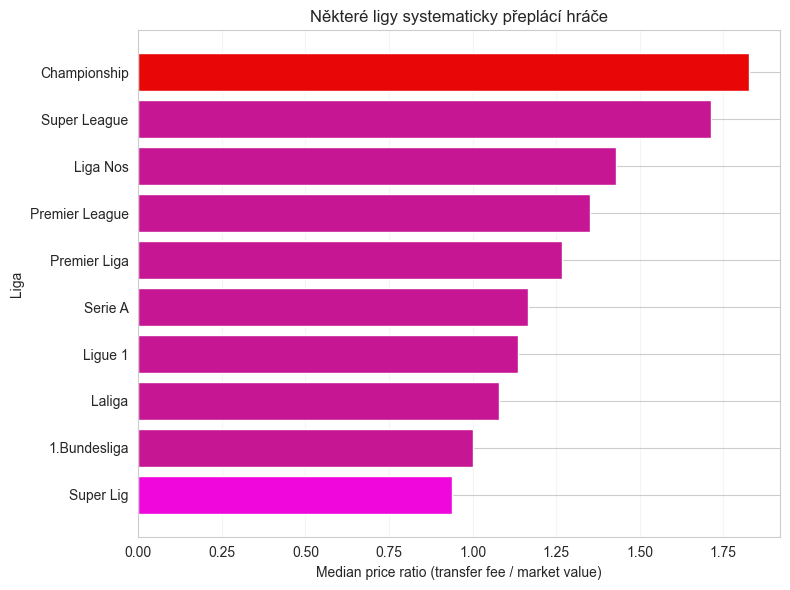

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata

# --- 1) NORMALIZACE TEXTU ---
def normalize_text(text):
    text = str(text)
    text = unicodedata.normalize('NFKD', text)
    text = text.encode('ascii', 'ignore').decode('utf-8')
    return text.lower().strip()

df_work["Nová  Liga"] = df_work["Nová  Liga"].apply(normalize_text)

# --- 2) AGREGACE ---
league_to_stats = (
    df_work
    .groupby("Nová  Liga")["price_ratio"]
    .agg(["median", "mean", "count"])
)

# --- 3) FILTR ---
league_to_filtered = league_to_stats[league_to_stats["count"] >= 30]

# --- 4) TOP / BOTTOM ---
top_cheap = league_to_filtered.nsmallest(5, "median")
top_expensive = league_to_filtered.nlargest(5, "median")

plot_df = pd.concat([top_cheap, top_expensive]).sort_values("median")


plot_df.index = plot_df.index.str.title()

# --- 6) PLOT ---
fig, ax = plt.subplots(figsize=(8, 6))

# zvýraznění extrémů
colors = ["#C61694"] * len(plot_df)
colors[0] = "#EF07DC"   # nejnižší
colors[-1] = "#E90606"  # nejvyšší

ax.barh(plot_df.index, plot_df["median"], color=colors)

# popisky
ax.set_xlabel("Median price ratio (transfer fee / market value)")
ax.set_ylabel("Liga")

# title 
ax.set_title("Některé ligy systematicky přeplácí hráče")

# grid
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

### Insight

Cílová liga (kam hráč přestupuje) má zásadní vliv na míru přeplácení – některé ligy systematicky přeplácí hráče.

### Evidence

Např. Championship nebo Super League vykazují výrazně vyšší median price_ratio, zatímco ligy jako Bundesliga nebo Super Lig se pohybují blíže tržní hodnotě.

### Interpretation

To naznačuje, že přeplácení není náhodné, ale souvisí s poptávkou a finanční strukturou konkrétních lig.  
Bohatší nebo méně efektivní ligy mohou vytvářet tlak na vyšší přestupové částky.

Ve srovnání s předchozími výsledky se zdá, že cílová liga má silnější vliv než původ hráče i samotný klub.

zaver ...

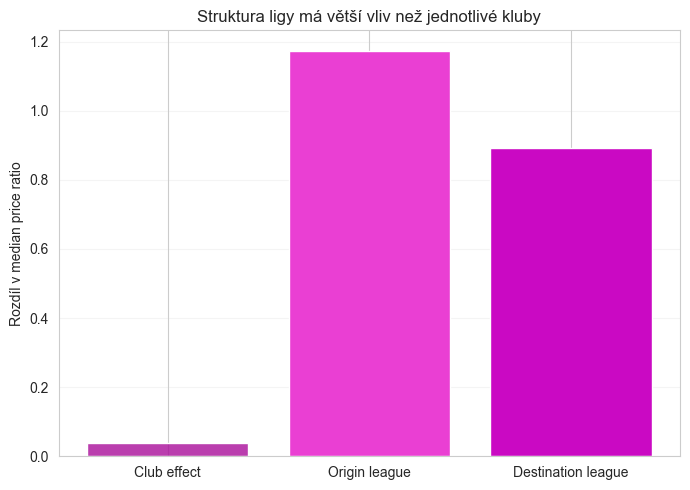

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


club_diff = abs(
    df_work.groupby("is_top_buying_club")["price_ratio"].median().diff().iloc[-1]
)

league_from_diff = (
    league_from_filtered["median"].max() - league_from_filtered["median"].min()
)

league_to_diff = (
    league_to_filtered["median"].max() - league_to_filtered["median"].min()
)

# --- dataframe ---
final_df = pd.DataFrame({
    "Faktor": ["Club effect", "Origin league", "Destination league"],
    "Síla vlivu": [club_diff, league_from_diff, league_to_diff]
})

# --- plot ---
fig, ax = plt.subplots(figsize=(7, 5))

colors = ["#A80A98C9", "#EA3FD3", "#CA09C3"]

ax.bar(final_df["Faktor"], final_df["Síla vlivu"], color=colors)

# popisky
ax.set_ylabel("Rozdíl v median price ratio")
ax.set_title("Struktura ligy má větší vliv než jednotlivé kluby")

# grid
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

Rozdíl v median price_ratio mezi skupinami (vyšší = větší odchylka od tržní hodnoty)

Vidíme, že zatímco vliv jednotlivých klubů je minimální, struktura lig – zejména cílové ligy – výrazně formuje přestupové ceny

Na závěr jsem se snažila porovnat, které faktory mají největší vliv na odchylku ceny od tržní hodnoty.
Ukazuje se, že samotné kluby hrají relativně malou roli, zatímco struktura lig – zejména cílové ligy – má výrazně větší dopad.
To naznačuje, že přestupový trh je řízen spíše poptávkou na úrovni lig než individuálními rozhodnutími klubů.

Výsledky naznačují, že individuální rozhodnutí klubů mají menší vliv než struktura trhu.


## Další kroky a produkční využití

Pokud by měla být analýza využita v praxi:

- automatizace výpočtu metriky (price_ratio) v datové pipeline
- pravidelný refresh dat (např. sezónně)
- monitoring distribuce price_ratio v čase (detekce změn trhu)
- rozšíření o další faktory (pozice hráče, finanční síla klubů, časový trend)